In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [4]:
ml_df = pd.read_csv(
    "../data/processed/ml_dataset_corrected.csv"
)

ml_df.head()

,genus,interval,survived,occurrence_count,collection_count,environment_breadth,formation_breadth,duration,sampling_intensity,lat_range,lng_range,lazarus
0,Abichites,Changhsingian,0,119,81,4,4,1,119,13.610001,61.050003,0
1,Abrekia,Griesbachian,0,7,7,3,5,3,7,15.367334,33.908104,1
2,Abrekia,Smithian,0,7,7,3,5,3,7,15.367334,33.908104,1
3,Abrekia,Aegean,0,7,7,3,5,3,7,15.367334,33.908104,1
4,Abrekites,Smithian,0,7,6,5,3,1,7,6.222103,250.452507,0


In [5]:
X = ml_df.drop(
    columns=[
        "genus",
        "interval",
        "survived"
    ]
)

y = ml_df["survived"]

print(X.shape)

(2525, 9)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

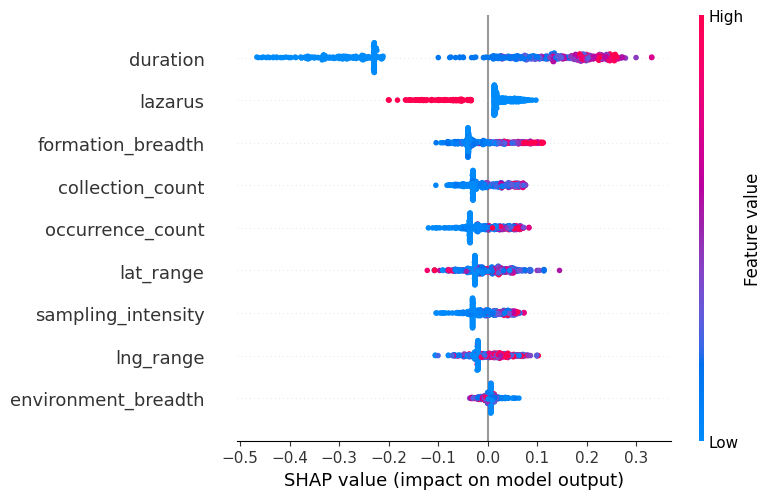

In [9]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

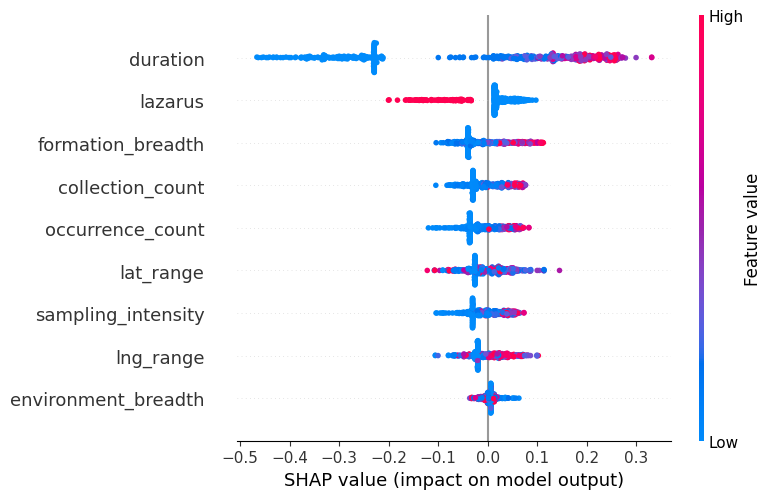

In [10]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

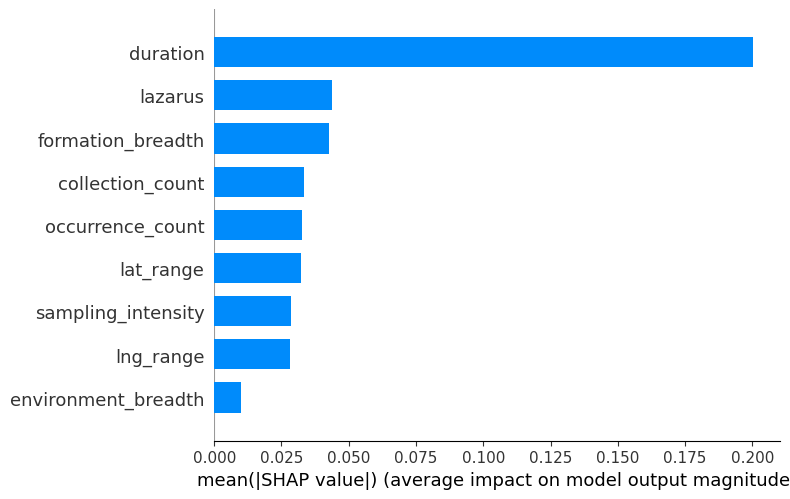

In [11]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

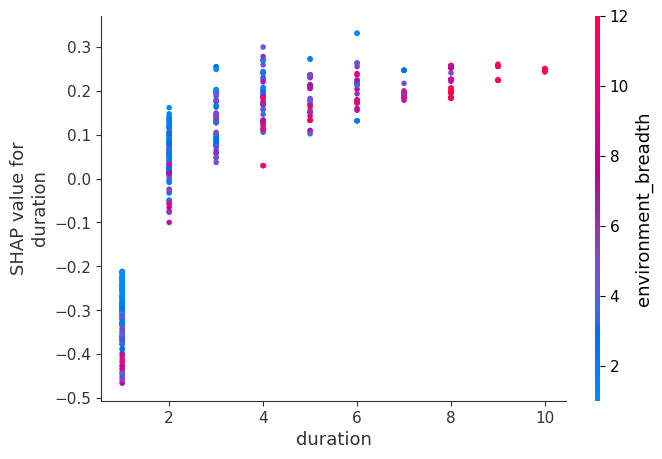

In [12]:
shap.dependence_plot(
    "duration",
    shap_values[:, :, 1],
    X_test
)

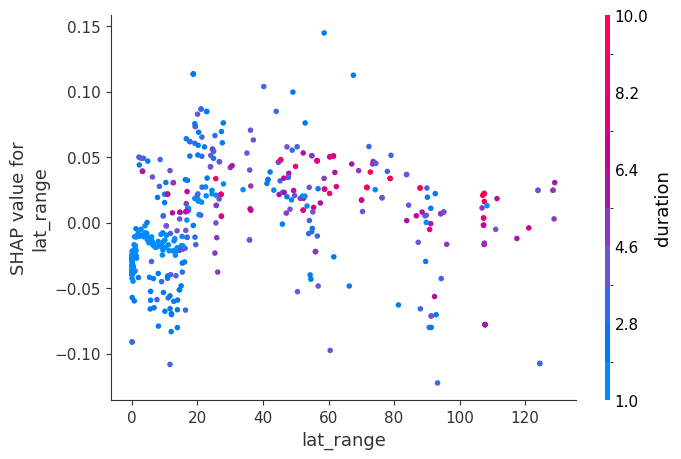

In [13]:
shap.dependence_plot(
    "lat_range",
    shap_values[:, :, 1],
    X_test
)

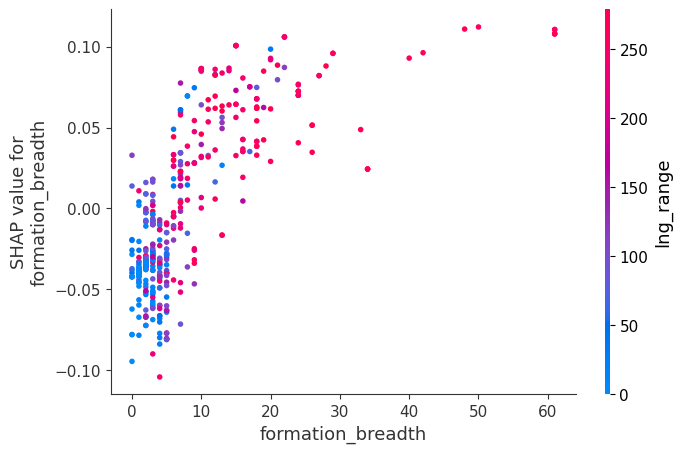

In [14]:
shap.dependence_plot(
    "formation_breadth",
    shap_values[:, :, 1],
    X_test
)

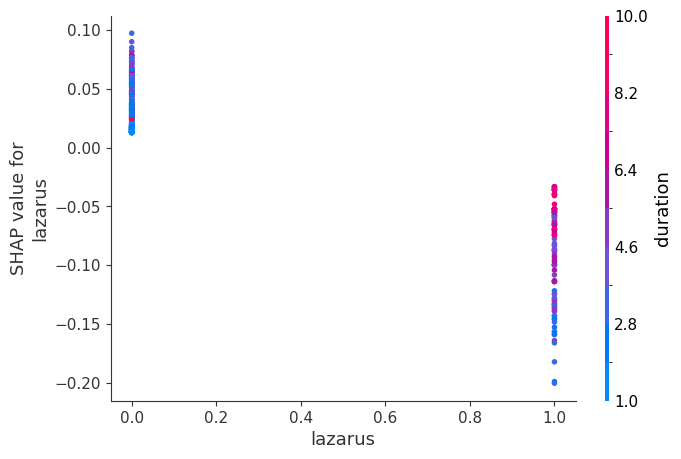

In [15]:
shap.dependence_plot(
    "lazarus",
    shap_values[:, :, 1],
    X_test
)

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": np.abs(
        shap_values[:, :, 1]
    ).mean(axis=0)
})

importance = importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

importance

,Feature,Mean_SHAP
4,duration,0.200275
8,lazarus,0.043666
3,formation_breadth,0.042589
1,collection_count,0.033314
0,occurrence_count,0.032786
6,lat_range,0.032152
5,sampling_intensity,0.028400
7,lng_range,0.028333
2,environment_breadth,0.009849


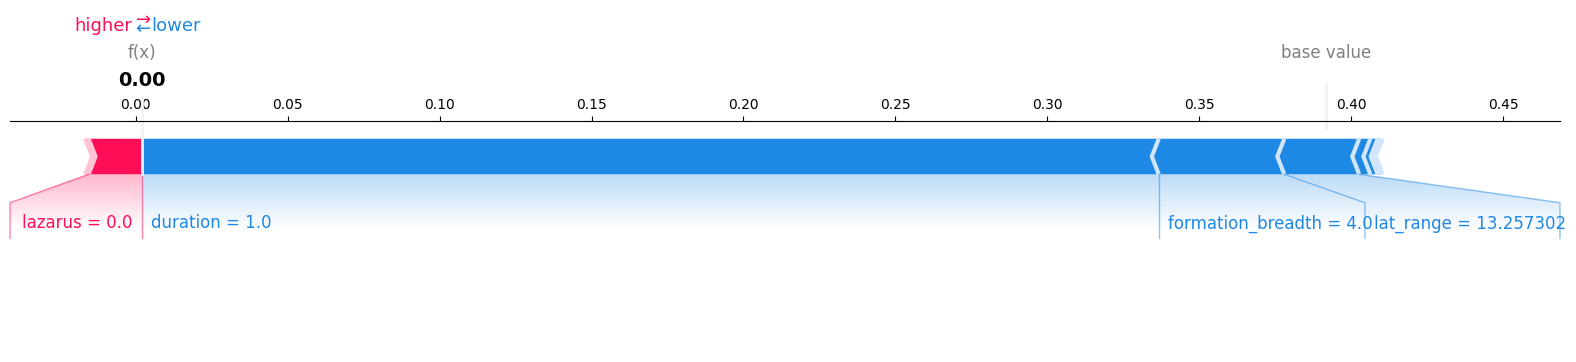

In [17]:
sample_index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    X_test.iloc[sample_index],
    matplotlib=True
)

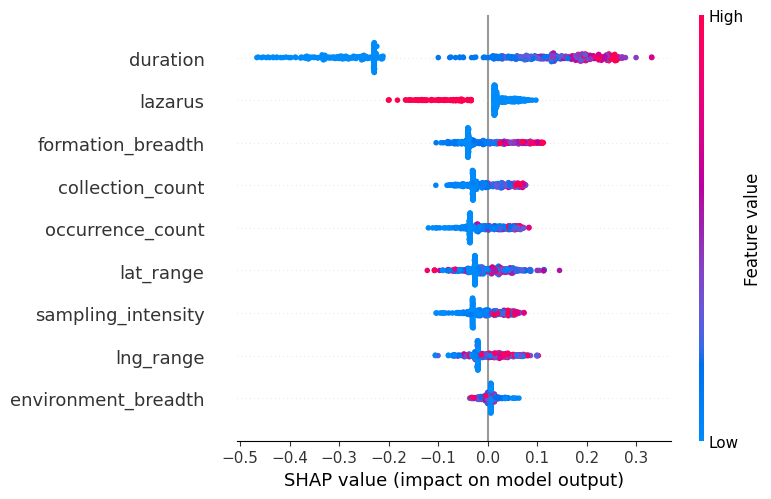

In [18]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [19]:
importance.head(10)

,Feature,Mean_SHAP
4,duration,0.200275
8,lazarus,0.043666
3,formation_breadth,0.042589
1,collection_count,0.033314
0,occurrence_count,0.032786
6,lat_range,0.032152
5,sampling_intensity,0.028400
7,lng_range,0.028333
2,environment_breadth,0.009849


In [22]:
import pandas as pd

for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame):
        print(name, "->", val.shape)

_ -> (9, 2)
__ -> (9, 2)
ml_df -> (2525, 12)
_4 -> (5, 12)
X -> (2525, 9)
X_train -> (2020, 9)
X_test -> (505, 9)
importance -> (9, 2)
_16 -> (9, 2)
_19 -> (9, 2)


In [23]:
print(importance.columns.tolist())  # confirm column names first
importance.to_csv("results/processed/shap_values_corrected.csv", index=False)
print("Saved corrected model SHAP summary")

['Feature', 'Mean_SHAP']


OSError: Cannot save file into a non-existent directory: 'results\processed'

In [24]:
import os
os.makedirs("results/processed", exist_ok=True)

In [28]:
import os
os.makedirs("../results/processed", exist_ok=True)

importance.to_csv("../results/processed/shap_values_corrected.csv", index=False)
print("Saved corrected model SHAP summary")

Saved corrected model SHAP summary


In [29]:
import os
print(os.path.exists("../results/processed/shap_values_corrected.csv"))

True


In [30]:
# Check what model object currently exists in memory
for name, val in list(globals().items()):
    if hasattr(val, "predict") and not name.startswith("_"):
        print(name, "->", type(val))

RandomForestClassifier -> <class 'abc.ABCMeta'>
rf -> <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [31]:
print(X_train.columns.tolist())

['occurrence_count', 'collection_count', 'environment_breadth', 'formation_breadth', 'duration', 'sampling_intensity', 'lat_range', 'lng_range', 'lazarus']


In [32]:
sampling_control_cols = ['collection_count', 'sampling_intensity', 'formation_breadth']

X_train_naive = X_train.drop(columns=sampling_control_cols)
X_test_naive = X_test.drop(columns=sampling_control_cols)

print(X_train_naive.columns.tolist())
print(X_train_naive.shape, X_test_naive.shape)

['occurrence_count', 'environment_breadth', 'duration', 'lat_range', 'lng_range', 'lazarus']
(2020, 6) (505, 6)


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_naive = RandomForestClassifier(
    n_estimators=rf.n_estimators,
    max_depth=rf.max_depth,
    random_state=rf.random_state
)
rf_naive.fit(X_train_naive, y_train)

print("Naive model trained")
print("Test accuracy:", rf_naive.score(X_test_naive, y_test))

Naive model trained
Test accuracy: 0.7247524752475247


In [34]:
import shap
import numpy as np
import pandas as pd

explainer_naive = shap.TreeExplainer(rf_naive)
shap_values_naive = explainer_naive.shap_values(X_test_naive)

print(type(shap_values_naive), "Shape:", np.array(shap_values_naive).shape)

<class 'numpy.ndarray'> Shape: (505, 6, 2)


In [35]:
shap_naive_class1 = np.array(shap_values_naive)[:, :, 1]
mean_abs_shap_naive = np.abs(shap_naive_class1).mean(axis=0)

importance_naive = pd.DataFrame({
    "feature": X_train_naive.columns,
    "mean_abs_shap": mean_abs_shap_naive
}).sort_values("mean_abs_shap", ascending=False)

print(importance_naive)

import os
os.makedirs("../results/processed", exist_ok=True)
importance_naive.to_csv("../results/processed/shap_values_naive.csv", index=False)
print("Saved naive model SHAP summary")

               feature  mean_abs_shap
2             duration       0.200297
0     occurrence_count       0.074425
4            lng_range       0.051295
3            lat_range       0.048100
5              lazarus       0.048005
1  environment_breadth       0.023592
Saved naive model SHAP summary


In [36]:
sampling_control_cols = ['collection_count', 'sampling_intensity', 'formation_breadth']

X_train_naive = X_train.drop(columns=sampling_control_cols)
X_test_naive = X_test.drop(columns=sampling_control_cols)

print(X_train_naive.columns.tolist())
print(X_train_naive.shape, X_test_naive.shape)

['occurrence_count', 'environment_breadth', 'duration', 'lat_range', 'lng_range', 'lazarus']
(2020, 6) (505, 6)


In [37]:
import shap
import numpy as np
import pandas as pd

explainer_naive = shap.TreeExplainer(rf_naive)
shap_values_naive = explainer_naive.shap_values(X_test_naive)

print(type(shap_values_naive), "Shape:", np.array(shap_values_naive).shape)

<class 'numpy.ndarray'> Shape: (505, 6, 2)


In [38]:
shap_naive_class1 = np.array(shap_values_naive)[:, :, 1]
mean_abs_shap_naive = np.abs(shap_naive_class1).mean(axis=0)

importance_naive = pd.DataFrame({
    "feature": X_train_naive.columns,
    "mean_abs_shap": mean_abs_shap_naive
}).sort_values("mean_abs_shap", ascending=False)

print(importance_naive)

import os
os.makedirs("../results/processed", exist_ok=True)
importance_naive.to_csv("../results/processed/shap_values_naive.csv", index=False)
print("Saved naive model SHAP summary")

               feature  mean_abs_shap
2             duration       0.200297
0     occurrence_count       0.074425
4            lng_range       0.051295
3            lat_range       0.048100
5              lazarus       0.048005
1  environment_breadth       0.023592
Saved naive model SHAP summary


In [39]:
import pandas as pd

for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame) and not name.startswith("_"):
        print(name, "->", val.shape)

ml_df -> (2525, 12)
X -> (2525, 9)
X_train -> (2020, 9)
X_test -> (505, 9)
importance -> (9, 2)
X_train_naive -> (2020, 6)
X_test_naive -> (505, 6)
importance_naive -> (6, 2)


In [40]:
print(ml_df.columns.tolist())
print(ml_df.head())

['genus', 'interval', 'survived', 'occurrence_count', 'collection_count', 'environment_breadth', 'formation_breadth', 'duration', 'sampling_intensity', 'lat_range', 'lng_range', 'lazarus']
       genus       interval  survived  occurrence_count  collection_count  \
0  Abichites  Changhsingian         0               119                81   
1    Abrekia   Griesbachian         0                 7                 7   
2    Abrekia       Smithian         0                 7                 7   
3    Abrekia         Aegean         0                 7                 7   
4  Abrekites       Smithian         0                 7                 6   

   environment_breadth  formation_breadth  duration  sampling_intensity  \
0                    4                  4         1                 119   
1                    3                  5         3                   7   
2                    3                  5         3                   7   
3                    3                  5       

In [41]:
import os
for f in os.listdir("../data/processed"):
    print(f)

features_genus.csv
feature_importance.csv
lazarus_taxa.csv
ml_dataset_corrected.csv
ml_dataset_naive.csv
model_comparison.csv
occurrences_clean.csv
presence_matrix.csv
survival_labels_genus.csv


In [42]:
import pandas as pd
occ_check = pd.read_csv("../data/processed/occurrences_clean.csv")
print(occ_check.columns.tolist())
print(occ_check.shape)
print(occ_check.head())

['accepted_name', 'early_interval', 'late_interval', 'collection_no', 'environment', 'formation', 'lat', 'lng', 'max_ma', 'min_ma']
(34945, 10)
          accepted_name early_interval late_interval  collection_no  \
0  Marginalosia planata  Changhsingian           NaN           7204   
1              Terrakea  Changhsingian           NaN           7204   
2          Spiriferella  Changhsingian           NaN           7204   
3              Martinia  Changhsingian           NaN           7204   
4             Tomiopsis  Changhsingian           NaN           7204   

  environment formation        lat         lng  max_ma   min_ma  
0         NaN  Stephens -41.299999  173.266663  254.14  251.902  
1         NaN  Stephens -41.299999  173.266663  254.14  251.902  
2         NaN  Stephens -41.299999  173.266663  254.14  251.902  
3         NaN  Stephens -41.299999  173.266663  254.14  251.902  
4         NaN  Stephens -41.299999  173.266663  254.14  251.902  


In [44]:
import pandas as pd

survival = pd.read_csv("../data/processed/survival_labels_genus.csv")
print(survival.columns.tolist())
print(survival.head())

['genus', 'interval', 'survived']
       genus       interval  survived
0  Abichites  Changhsingian         0
1    Abrekia   Griesbachian         0
2    Abrekia       Smithian         0
3    Abrekia         Aegean         0
4  Abrekites       Smithian         0


In [47]:
occ_path = DATA_PROCESSED / "occurrences_clean.csv"
survival_path = DATA_PROCESSED / "survival_labels_genus.csv"

have_occ = require_file(occ_path, "01_data_acquisition_cleaning.ipynb")
have_survival = require_file(survival_path, "03_survival_labels.ipynb")

if have_occ and have_survival:
    occ_raw = pd.read_csv(occ_path)
    survival = pd.read_csv(survival_path)

    # Rename to match what the map expects
    occ_raw = occ_raw.rename(columns={
        "accepted_name": "genus",
        "early_interval": "interval",
        "lat": "paleolat",   # NOTE: these are modern coordinates, not true
        "lng": "paleolng",   # paleocoordinates -- see caveat below
    })

    # Merge survival label onto each occurrence, matched on genus + interval
    occ_df = occ_raw.merge(survival, on=["genus", "interval"], how="inner")

    print("Merged shape:", occ_df.shape)
    print(occ_df[["genus", "interval", "paleolat", "paleolng", "survived"]].head())
else:
    occ_df = pd.DataFrame({
        "genus": [], "paleolat": [], "paleolng": [],
        "interval": [], "survived": []
    })

NameError: name 'DATA_PROCESSED' is not defined

In [46]:
print(os.getcwd())

f:\permian-triassic-survival-ml\notebooks
